**Question 1: What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.**

**Answer:** Anomaly detection (or outlier detection) is the machine learning task of identifying data points, events, or observations that deviate significantly from the expected baseline behavior of a dataset.

**Types**

1. Point Anomalies (Global Anomalies)
 > A single data instance deviates significantly from the rest of the entire dataset, regardless of external factors or surrounding context. For example, a credit card account with a historical average purchase of $50$ suddenly registers a single transaction of $25,000.

 2. Contextual Anomalies (Conditional Anomalies)
  > A data instance is anomalous only within a specific context (such as time, geographic location, or operational state), even though the same value would be normal under different circumstances.

  3. Collective Anomalies
   > A collection or sequence of related data points appears anomalous when evaluated together, even if the individual data points within the sequence seem normal on their own. For Example: On an electrocardiogram (ECG), a single low-voltage heartbeat reading is normal, but a continuous sequence of identical low-voltage readings over 10 seconds (a flatline) represents a severe collective anomaly indicating cardiac arrest.

---

**Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.**

**Answer:** Isolation Forest, DBSCAN, and Local Outlier Factor (LOF) offer distinct approaches to anomaly detection based on random partitioning, global spatial density, and relative local density.

1. Isolation Forest (iForest):

Isolation-based tree ensemble that randomly partitions feature space; anomalies isolate near tree roots with short average path lengths.

Anomaly Scope: Global point anomalies.

Time Complexity: $\mathcal{O}(n \log n)$, making it exceptionally scalable to massive datasets.

High-Dimensional Data: Excellent performance; highly resilient to the curse of dimensionality.

Cluster Density Handling: Moderate capability on datasets with varying cluster densities.

**Suitable Use Cases:** Large-scale tabular data, real-time credit card fraud detection, and network intrusion monitoring.

2. DBSCAN

Global spatial density clustering that groups points exceeding a density threshold ($\text{minPts}$ within radius $\epsilon$); unassigned sparse points are labeled as noise.

Anomaly Scope: Noise and outliers surrounding dense spatial clusters.Time Complexity: $\mathcal{O}(n \log n)$ to $\mathcal{O}(n^2)$, depending on spatial indexing efficiency.

High-Dimensional Data: Poor performance; distance metrics break down in high-dimensional feature spaces.

Cluster Density Handling: Poor performance on variable-density clusters due to its requirement for a single fixed global radius $\epsilon$.

**Suitable Use Cases:** Low-dimensional spatial/geospatial data, non-spherical cluster segmentation, and simultaneous clustering with noise filtering.


3. Local Outlier Factor (LOF)

Local density ratio calculation that compares a point's local reachability density against that of its $k$-nearest neighbors.

Anomaly Scope: Local, contextual, or relative-density anomalies.Time Complexity: $\mathcal{O}(n^2)$ due to pairwise nearest-neighbor computations.

High-Dimensional Data: Moderate performance; efficiency degrades in sparse high-dimensional spaces.

Cluster Density Handling: Excellent performance; compares relative local density rather than assuming uniform global density.

**Suitable Use Cases:** Datasets containing multiple clusters with vastly different densities, localized medical anomaly detection, and regional sensor failure monitoring.

---

**Question 3: What are the key components of a Time Series? Explain each with one example.**

**Answer:** A Time Series is a sequence of data points recorded at successive, equally spaced time intervals. It is typically decomposed into four fundamental components:

1. Trend ($T$)

> The overall long-term direction or systematic movement of the data over an extended period, which can be upward, downward, or stationary.

> Example: The continuous, multi-decade increase in global internet bandwidth usage or global mean sea levels.

2. Seasonality ($S$)

> Repetitive, predictable patterns or fluctuations that recur at fixed, regular intervals within a specific timeframe (e.g., daily, weekly, monthly, or quarterly).

> Example: Retail clothing sales surging every year during the November–December holiday shopping season, or electricity demand peaking every afternoon during summer.

3. Cyclical Component ($C$)

> Multi-year wave-like oscillations around a trend that repeat without fixed or predictable periodicities, usually driven by economic or business cycles.

> Example: Fluctuations in real estate market prices expanding and contracting over 5-to-10-year macroeconomic business cycles.

4. Irregular / Noise Component ($I$)

> Unpredictable, random residual variations caused by erratic, unforeseen, or non-recurring external events.

> Example: A sudden, dramatic drop in global supply chain shipments due to an unexpected volcanic eruption or geopolitical conflict.

---

**Question 4: Define Stationary in time series. How can you test and transform a
non-stationary series into a stationary one?**

**Answer:** A time series is stationary if its statistical properties—such as mean, variance, and autocorrelation—remain constant over time, meaning the series exhibits no trend or seasonality.

**Properties:** Constant Mean, Variance and Autocovariance.

**Testing for Stationarity:** Visual Inspection, Augmented Dickey-Fuller (ADF) Test, Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test.


**Transforming Non-Stationary Series into Stationary**

1. Differencing (Removes Trend & Seasonality):

First-order Differencing: Subtracts the previous observation from the current observation to remove linear trends:$$y'_t = y_t - y_{t-1}$$

Seasonal Differencing: Subtracts the observation from the corresponding period of the previous season (e.g., $m = 12$ for monthly data):$$y'_t = y_t - y_{t-m}$$

2. Logarithmic / Power Transformations (Stabilizes Variance):

Apply $\log(y_t)$ or Box-Cox transformation when the series exhibits exponential growth or expanding variance over time.


3. Detrending via Regression:

Fit a deterministic trend line (e.g., linear or polynomial regression) to $y_t$ and extract the residual series ($e_t = y_t - \hat{y}_t$).

---

**Question 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in
terms of structure and application**

**Answer:**

**AR (Autoregressive)**

Parameters: $p$

Mathematical Structure: $y_t = c + \sum_{i=1}^p \phi_i y_{t-i} + \epsilon_t$

Key Mechanism: Regresses the current value on its own past $p$ values (historical memory).

Best Application: Stationary series with persistent momentum (e.g., daily ambient temperature).

**MA (Moving Average)**

Parameters: $q$

Mathematical Structure: $y_t = c + \epsilon_t + \sum_{j=1}^q \theta_j \epsilon_{t-j}$

Key Mechanism: Regresses the current value on past $q$ white-noise forecast errors (shocks).

Best Application: Short-term shock-driven series that self-correct quickly (e.g., financial market returns).

**ARIMA (Non-Seasonal Autoregressive Integrated Moving Average)**

Parameters: $(p, d, q)$

Mathematical Structure: $\phi(B)(1-B)^d y_t = c + \theta(B)\epsilon_t$

Key Mechanism: Combines AR, MA, and $d$-order differencing ($(1-B)^d$) to handle non-stationarity.

Best Application: Non-stationary univariate series with trends but no seasonality (e.g., national annual GDP).

**SARIMA (Seasonal ARIMA)**

Parameters: $(p,d,q)(P,D,Q)_s$

Mathematical Structure: $\Phi_P(B^s)\phi_p(B)(1-B)^d(1-B^s)^D y_t = \Theta_Q(B^s)\theta_q(B)\epsilon_t$

Key Mechanism: Integrates seasonal AR ($P$), differencing ($D$), and MA ($Q$) over period length $s$.

Best Application: Non-stationary series with distinct repeating seasonal cycles (e.g., monthly airline passenger volume).

**SARIMAX (Seasonal ARIMA with Exogenous Variables)**

Parameters: $(p,d,q)(P,D,Q)_s + X_t$

Mathematical Structure: Extends the SARIMA equation by adding an exogenous covariate matrix $\sum_{k} \beta_k X_{k,t}$.

Key Mechanism: Integrates external explanatory drivers ($X_t$) alongside historical autoregressive patterns.

Best Application: Seasonal target series influenced by external forces (e.g., daily power grid demand driven by weather forecasts).

Air Passengers Data set Link: https://drive.google.com/file/d/1eu6DQtqaH2qmJZU_RU5tQe5hhYejjXW3/view?usp=sharing

NYC Taxi Fare data: https://drive.google.com/file/d/1NgjnaMX_41yLiutbeM4Dpv6yQdDf82zm/view?usp=sharing

Downloading...
From: https://drive.google.com/uc?id=1eu6DQtqaH2qmJZU_RU5tQe5hhYejjXW3
To: /content/AirPassengers.csv
100%|██████████| 1.75k/1.75k [00:00<00:00, 7.23MB/s]



Dataset Summary:
            #Passengers
Month                  
1949-01-01          112
1949-02-01          118
1949-03-01          132
1949-04-01          129
1949-05-01          121


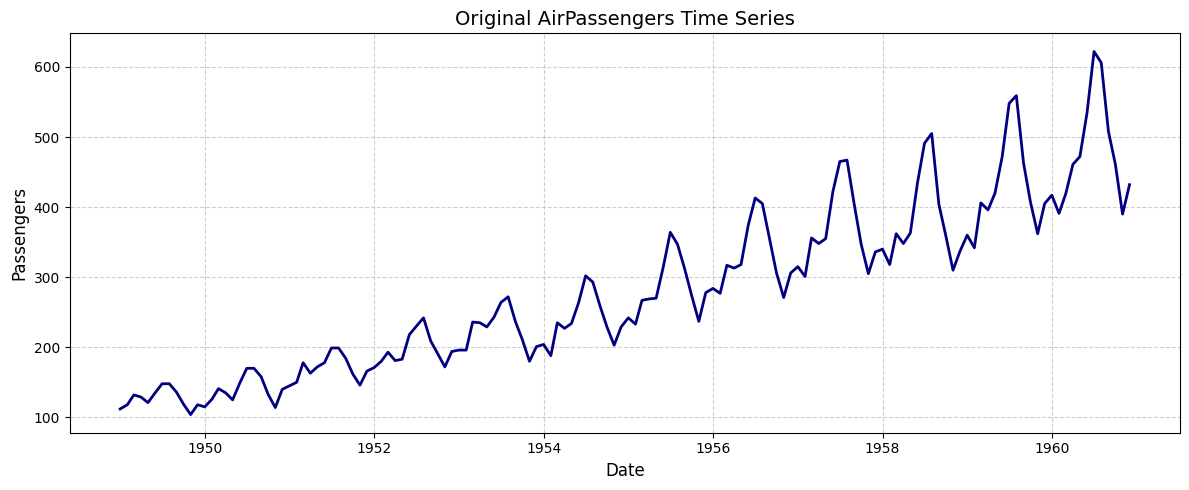

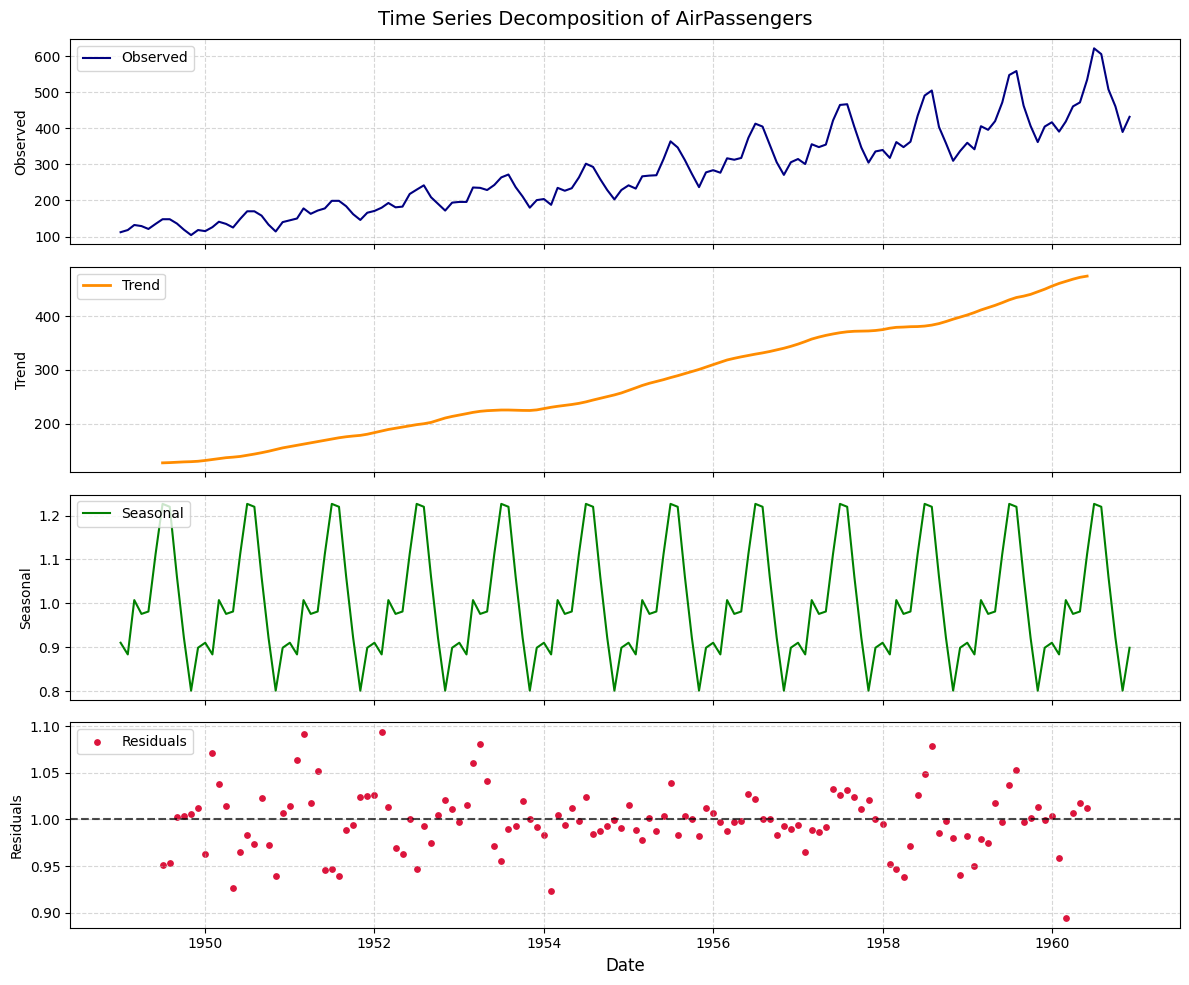

In [3]:
'''
**Question 6: Load a time series dataset (e.g., AirPassengers), plot the
original series, and decompose it into trend, seasonality, and residual
components**
'''

import matplotlib.pyplot as plt
import gdown
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose


# 1. Downloading data set

# Extract file ID: 1eu6DQtqaH2qmJZU_RU5tQe5hhYejjXW3
file_id = '1eu6DQtqaH2qmJZU_RU5tQe5hhYejjXW3'
gdrive_url = f'https://drive.google.com/uc?id={file_id}'

output_filename = 'AirPassengers.csv'
gdown.download(gdrive_url, output_filename, quiet=False)


# 2. Load & Preprocess the Dataset

df = pd.read_csv(output_filename)

# identify the date column and numeric data column
date_col = df.columns[0]
value_col = df.columns[1]

# Convert date column to datetime format and set as DatetimeIndex
df[date_col] = pd.to_datetime(df[date_col])
df.set_index(date_col, inplace=True)

# Assign monthly frequency ('MS' = Month Start)
df.index.freq = 'MS'

print("\nDataset Summary:")
print(df.head())


# 3. Plot Original Time Series

plt.figure(figsize=(12, 5))
plt.plot(df.index, df[value_col], color='navy', linewidth=2)
plt.title('Original AirPassengers Time Series', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Passengers', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# 4. Decomposition of Time Series (Trend, Seasonality, Residuals)

# Multiplicative model accounts for growing seasonal variance over time
decomposition = seasonal_decompose(
    df[value_col], model='multiplicative', period=12
)

# Plot components
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# Observed
axes[0].plot(df[value_col], label='Observed', color='navy')
axes[0].set_ylabel('Observed')
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Trend
axes[1].plot(decomposition.trend, label='Trend', color='darkorange', linewidth=2)
axes[1].set_ylabel('Trend')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Seasonality
axes[2].plot(decomposition.seasonal, label='Seasonal', color='green')
axes[2].set_ylabel('Seasonal')
axes[2].legend(loc='upper left')
axes[2].grid(True, linestyle='--', alpha=0.5)

# Residuals / Noise
axes[3].scatter(
    decomposition.resid.index,
    decomposition.resid,
    label='Residuals',
    color='crimson',
    s=15,
)
axes[3].axhline(1.0, color='black', linestyle='--', alpha=0.7)
axes[3].set_ylabel('Residuals')
axes[3].legend(loc='upper left')
axes[3].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Time Series Decomposition of AirPassengers', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.tight_layout()
plt.show()

Downloading...
From (original): https://drive.google.com/uc?id=1NgjnaMX_41yLiutbeM4Dpv6yQdDf82zm
From (redirected): https://drive.google.com/uc?id=1NgjnaMX_41yLiutbeM4Dpv6yQdDf82zm&confirm=t&uuid=9336096b-c17e-4aec-86fd-d589308ecb5e
To: /content/nyc_taxi_dataset.csv
100%|██████████| 594M/594M [00:08<00:00, 68.1MB/s]
/tmp/ipykernel_2498/2066109703.py:23: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(output_filename)


Dataset Preview:
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0       1.0  2020-01-01 00:28:15   2020-01-01 00:33:03              1.0   
1       1.0  2020-01-01 00:35:39   2020-01-01 00:43:04              1.0   
2       1.0  2020-01-01 00:47:41   2020-01-01 00:53:52              1.0   
3       1.0  2020-01-01 00:55:23   2020-01-01 01:00:14              1.0   
4       2.0  2020-01-01 00:01:58   2020-01-01 00:04:16              1.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0            1.2         1.0                  N           238           239   
1            1.2         1.0                  N           239           238   
2            0.6         1.0                  N           238           238   
3            0.8         1.0                  N           238           151   
4            0.0         1.0                  N           193           193   

   payment_type  fare_amount  extra  mta_tax  tip_amount 

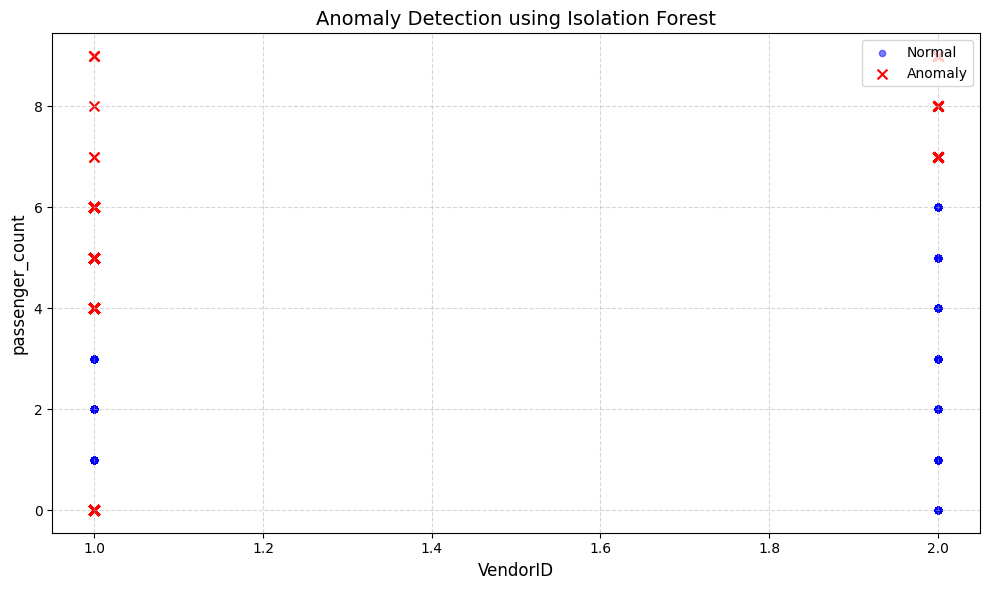

In [4]:
'''
Question 7: Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare)
to detect anomalies. Visualize the anomalies on a 2D scatter plot
'''
import matplotlib.pyplot as plt
import gdown
import pandas as pd
from sklearn.ensemble import IsolationForest


# 1. Download Dataset

# Extract file ID from link: 1NgjnaMX_41yLiutbeM4Dpv6yQdDf82zm
file_id = '1NgjnaMX_41yLiutbeM4Dpv6yQdDf82zm'
gdrive_url = f'https://drive.google.com/uc?id={file_id}'

output_filename = 'nyc_taxi_dataset.csv'
gdown.download(gdrive_url, output_filename, quiet=False)


# 2. Load & Select Numerical Features

df = pd.read_csv(output_filename)

print("Dataset Preview:")
print(df.head())

# Extract numerical columns for clustering/anomaly detection
num_df = df.select_dtypes(include=['float64', 'int64']).dropna()

# Pick first two prominent numerical features for 2D visualization

num_cols = num_df.columns.tolist()
feature_x = num_cols[0]
feature_y = num_cols[1] if len(num_cols) > 1 else num_cols[0]

X = num_df[[feature_x, feature_y]]


# 3. Applying Isolation Forest

# contamination=0.03 assumes roughly 3% of the data points are anomalies
iso_forest = IsolationForest(contamination=0.03, random_state=42)
num_df['anomaly'] = iso_forest.fit_predict(X)

# Isolation Forest tags inliers as 1 and anomalies as -1
inliers = num_df[num_df['anomaly'] == 1]
anomalies = num_df[num_df['anomaly'] == -1]

print(f"\nTotal Samples: {len(num_df)}")
print(f"Detected Normal Points: {len(inliers)}")
print(f"Detected Anomalies: {len(anomalies)}")


# 4. Visualization

plt.figure(figsize=(10, 6))

#  normal points
plt.scatter(
    inliers[feature_x],
    inliers[feature_y],
    c='blue',
    label='Normal',
    alpha=0.5,
    s=20,
)

#  anomalies
plt.scatter(
    anomalies[feature_x],
    anomalies[feature_y],
    c='red',
    label='Anomaly',
    marker='x',
    s=50,
    linewidths=1.5,
)

plt.title('Anomaly Detection using Isolation Forest', fontsize=14)
plt.xlabel(feature_x, fontsize=12)
plt.ylabel(feature_y, fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Downloading...
From: https://drive.google.com/uc?id=1eu6DQtqaH2qmJZU_RU5tQe5hhYejjXW3
To: /content/AirPassengers.csv
100%|██████████| 1.75k/1.75k [00:00<00:00, 5.11MB/s]


SARIMA Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:                        #Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -456.103
Date:                            Tue, 11 Aug 2026   AIC                            922.205
Time:                                    20:18:53   BIC                            936.016
Sample:                                01-01-1949   HQIC                           927.812
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2298      0.401     -0.573      0.567      -1.016       0.557
ma.L1        

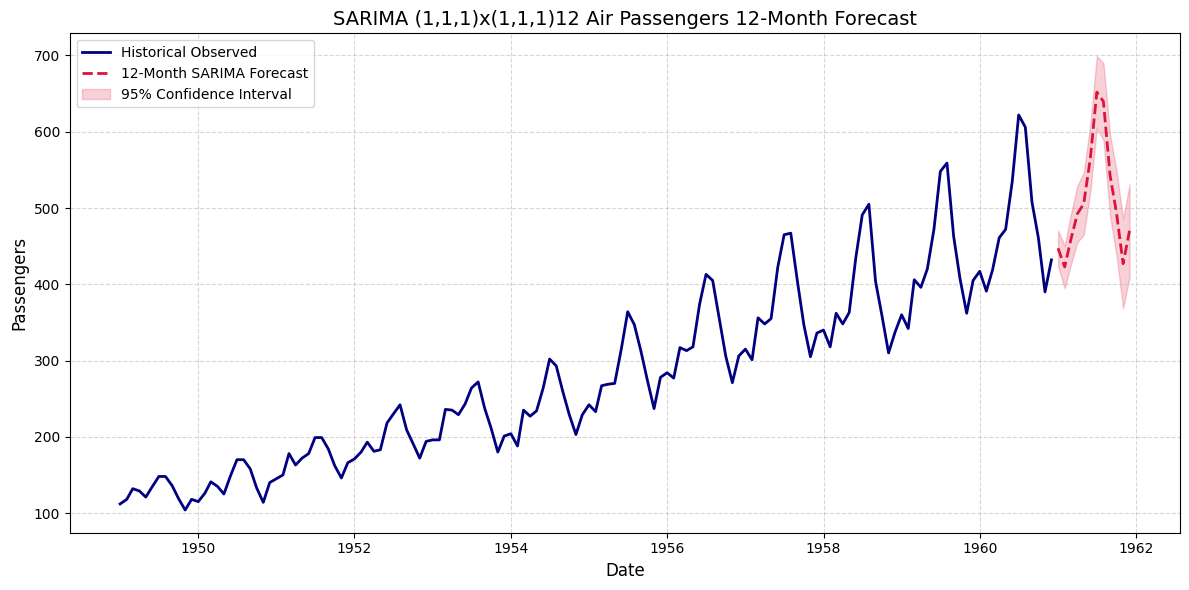

In [5]:
'''
Question 8: Train a SARIMA model on the monthly airline passengers dataset.
Forecast the next 12 months and visualize the results
'''

import matplotlib.pyplot as plt
import gdown
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX


# 1. Download Dataset

file_id = '1eu6DQtqaH2qmJZU_RU5tQe5hhYejjXW3'
gdrive_url = f'https://drive.google.com/uc?id={file_id}'

output_filename = 'AirPassengers.csv'
gdown.download(gdrive_url, output_filename, quiet=False)


# 2. Load and Prepare the Time Series Data

df = pd.read_csv(output_filename)

date_col = df.columns[0]
value_col = df.columns[1]

df[date_col] = pd.to_datetime(df[date_col])
df.set_index(date_col, inplace=True)
df.index.freq = 'MS'  # Monthly frequency (Month Start)

series = df[value_col]


# 3. Training SARIMA Model

# Order parameters:
# (p, d, q) = (1, 1, 1) -> Non-seasonal AR, Differencing, MA
# (P, D, Q, s) = (1, 1, 1, 12) -> Seasonal AR, Seasonal Differencing, Seasonal MA (12 months)
sarima_model = SARIMAX(
    series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

results = sarima_model.fit(disp=False)
print("SARIMA Model Summary:")
print(results.summary())

# 4. Forecast Next 12 Months

forecast_steps = 12
forecast_obj = results.get_forecast(steps=forecast_steps)

# Mean forecasted values
forecast_values = forecast_obj.predicted_mean

# 95% Confidence interval upper and lower bounds
confidence_intervals = forecast_obj.conf_int(alpha=0.05)

print("\n12-Month Forecasted Passenger Values:")
print(forecast_values)


# 5. Visualizing Historical Data & 12-Month Forecast

plt.figure(figsize=(12, 6))

# Historical Data
plt.plot(series.index, series, label='Historical Observed', color='navy', lw=2)

# Forecasted Values
plt.plot(
    forecast_values.index,
    forecast_values,
    label='12-Month SARIMA Forecast',
    color='crimson',
    lw=2,
    linestyle='--',
)

# Confidence Interval Range
plt.fill_between(
    confidence_intervals.index,
    confidence_intervals.iloc[:, 0],
    confidence_intervals.iloc[:, 1],
    color='crimson',
    alpha=0.2,
    label='95% Confidence Interval',
)

plt.title(
    'SARIMA (1,1,1)x(1,1,1)12 Air Passengers 12-Month Forecast', fontsize=14
)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Passengers', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Downloading...
From: https://drive.google.com/uc?id=1eu6DQtqaH2qmJZU_RU5tQe5hhYejjXW3
To: /content/AirPassengers.csv
100%|██████████| 1.75k/1.75k [00:00<00:00, 6.48MB/s]


Total Observations: 144
Normal Observations: 139
Anomalies Detected: 5


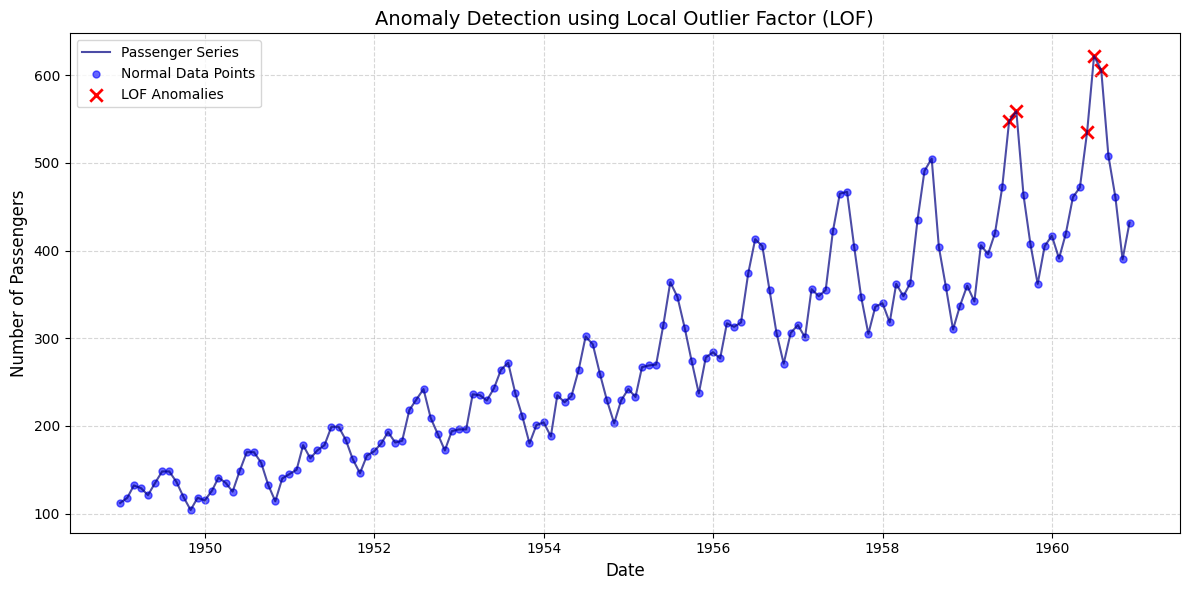

In [6]:
'''
Question 9: Apply Local Outlier Factor (LOF) on any numerical dataset to detect
anomalies and visualize them using matplotlib.
'''

import matplotlib.pyplot as plt
import gdown
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor


# 1. Download Dataset

file_id = '1eu6DQtqaH2qmJZU_RU5tQe5hhYejjXW3'
gdrive_url = f'https://drive.google.com/uc?id={file_id}'

output_filename = 'AirPassengers.csv'
gdown.download(gdrive_url, output_filename, quiet=False)


# 2. Load and Preprocess the Dataset

df = pd.read_csv(output_filename)

date_col = df.columns[0]
value_col = df.columns[1]

df[date_col] = pd.to_datetime(df[date_col])
df.set_index(date_col, inplace=True)

#  data changing for scikit-learn model input (2D array)
X = df[[value_col]].values

# 3. Apply Local Outlier Factor (LOF)

# n_neighbors specifies the number of neighbors to compare local density
# contamination specifies the expected proportion of outliers in the data
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
df['anomaly'] = lof.fit_predict(X)

# Separate normal data points (1) and detected anomalies (-1)
inliers = df[df['anomaly'] == 1]
anomalies = df[df['anomaly'] == -1]

print(f"Total Observations: {len(df)}")
print(f"Normal Observations: {len(inliers)}")
print(f"Anomalies Detected: {len(anomalies)}")


# 4. Visualizing Results using Matplotlib

plt.figure(figsize=(12, 6))

# Plot normal time series line and points
plt.plot(
    df.index,
    df[value_col],
    color='navy',
    linewidth=1.5,
    alpha=0.7,
    label='Passenger Series',
)
plt.scatter(
    inliers.index,
    inliers[value_col],
    color='blue',
    s=25,
    alpha=0.6,
    label='Normal Data Points',
)

# Highlight detected local anomalies
plt.scatter(
    anomalies.index,
    anomalies[value_col],
    color='red',
    marker='x',
    s=80,
    linewidths=2,
    label='LOF Anomalies',
)

plt.title('Anomaly Detection using Local Outlier Factor (LOF)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Question 10:You are working as a data scientist for a power grid monitoring company.**
**Your goal is to forecast energy demand and also detect abnormal spikes or drops in real-time consumption data collected every 15 minutes. The dataset includes features like timestamp, region, weather conditions, and energy usage.
Explain your real-time data science workflow:**

**● How would you detect anomalies in this streaming data (Isolation Forest / LOF / DBSCAN)?**

**● Which time series model would you use for short-term forecasting (ARIMA /
SARIMA / SARIMAX)?**

**● How would you validate and monitor the performance over time?**

**● How would this solution help business decisions or operations?**


**Answer:** Since the time gap is of 15 minutes, in my opinion, Isolation Forest integrated with a rolling window (e.g., 24–48 hours) is the most viable approach because of the following reason:

1.  Isolation Forest operates at $\mathcal{O}(n \log n)$ complexity, enabling low-latency inference on fast streams. By contrast, LOF and DBSCAN rely on $\mathcal{O}(n^2)$ pairwise distance calculations, making them computationally prohibitive for real-time processing.

2. To detect meaningful power spikes or drops, raw consumption values are combined with contextual features inside the streaming pipeline—such as rolling mean, variance, and time-of-day offsets. An isolation tree isolating a data point near its root indicates an abnormal deviation relative to recent grid conditions.

**Short-Term Forecasting Model: SARIMAX**

SARIMAX directly incorporates external weather drivers alongside historical load data as Power consumption is heavily driven by environmental conditions. Collected at 15-minute intervals, grid data yields 96 periods per day ($s = 96$). SARIMAX models both non-stationary load trends and strong daily/weekly intraday cycles.

**Model Validation & Continuous Monitoring**

> Walk-Forward Validation: Evaluates model accuracy using expanding or rolling time-series split windows, simulating real-world operational forecasts while preventing look-ahead leakage.

> Real-Time Error Tracking: Continuously monitors forecast health across rolling windows using Mean Absolute Percentage Error (MAPE) and Weighted Absolute Percentage Error (WAPE).

> Drift & Alerting: Monitors incoming weather distributions and consumption patterns for data drift via the Kolmogorov-Smirnov (KS) test and Population Stability Index (PSI). Automated alerts trigger model retraining whenever forecast error exceeds predefined thresholds.

**Business & Operational Impact**


> Grid Stability: Real-time anomaly detection provides early warnings for sudden load spikes or unexpected drops, allowing operators to adjust spinning reserves before grid instability or blackouts occur.

> Cost Optimization: Accurate short-term SARIMAX forecasts prevent over-generation and minimize reliance on expensive peaker plants or costly spot-market electricity purchases.

> Asset Maintenance: Spotting localized abnormal draw down or voltage surges enables preventive isolation, protecting transformers and grid infrastructure from thermal overload.